In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv('ford.csv')

In [32]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [33]:
df.shape

(17966, 9)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [35]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [36]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [37]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [38]:
df.duplicated().value_counts()

False    17812
True       154
Name: count, dtype: int64

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df.shape

(17812, 9)

<Axes: xlabel='price', ylabel='Count'>

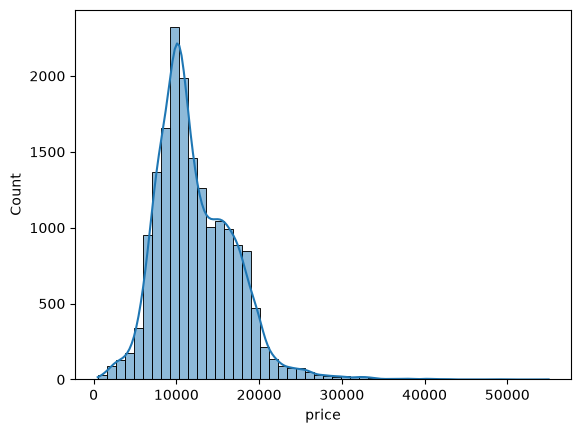

In [41]:
# checking the distribution of the price target column
sns.histplot(data=df,x='price',bins=50,kde= True)

In [42]:
# check the correlation 
corr = df.corr(method='pearson',numeric_only=True)
corr

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.635715,-0.708690,0.297183,-0.021702,-0.137582
price,0.635715,1.000000,-0.530483,0.405969,-0.346263,0.411451
mileage,-0.708690,-0.530483,1.000000,-0.257543,0.117697,0.214692
tax,0.297183,0.405969,-0.257543,1.000000,-0.502343,0.185358
mpg,-0.021702,-0.346263,0.117697,-0.502343,1.000000,-0.262239
engineSize,-0.137582,0.411451,0.214692,0.185358,-0.262239,1.000000


<Axes: >

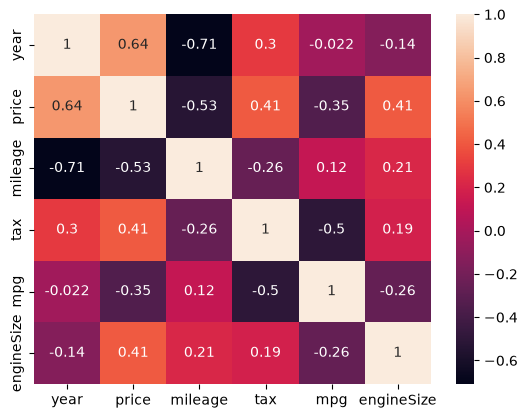

In [43]:
# heat map 
sns.heatmap(data = corr,annot=True)

In [44]:
# box plot comparing for different variables with price
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


<Axes: xlabel='year', ylabel='price'>

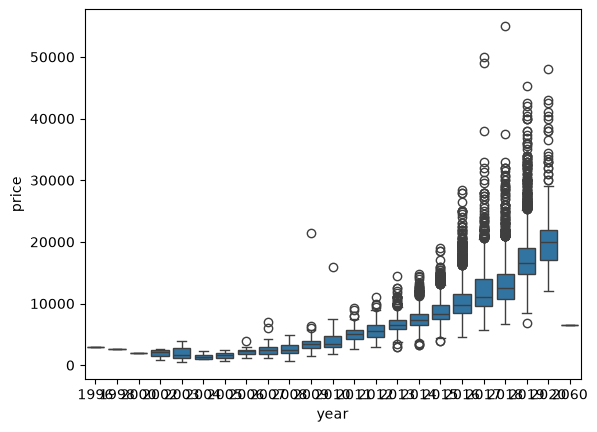

In [45]:
sns.boxplot(data = df,x='year',y='price')

In [46]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [64]:
X = df.drop('price',axis=1)
Y = df['price']

In [65]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0


In [66]:
X.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

## One hot encoding

In [58]:
X_one_hot_encode = pd.get_dummies(data =X,drop_first=True,dtype=int)

In [59]:
X_one_hot_encode.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [61]:
cols = ['year','mileage','tax','mpg','engineSize']

In [88]:
X_one_hot_encode[cols]=scaler.fit_transform(X[cols])

In [89]:
X_one_hot_encode.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.068917,-0.251285,0.630186,0.233592,-0.918516,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.563098,-0.958395,0.630186,0.233592,-0.918516,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.068917,-0.601908,0.630186,0.233592,-0.918516,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.057280,-0.809731,0.418739,-2.073185,0.486190,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.057280,-1.592067,0.418739,-0.791642,-0.918516,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [90]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_one_hot_encode,Y,test_size=0.2,random_state=42)

In [91]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [92]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 2281.21,-1316.96, -177.84,..., 5068.92, 1752.18, 209.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.033e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [93]:
from sklearn.metrics import r2_score

In [94]:
y_pred = model.predict(x_test)

In [95]:
r2=r2_score(y_true = y_test,y_pred = y_pred)
r2

0.8614598602291349

In [96]:
n = x_test.shape[0]
p = x_test.shape[1]

In [97]:
adjusted_r2 = 1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2

0.860124722827715

### here using the one hot encoding the both r2 and adjusted r2 both are quite near to each other so good in this case

## Label Encoding

In [77]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [99]:
X_label_encode = X.copy()
X_label_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,18,Automatic,5583,Petrol,11,69,1
1,Focus,19,Manual,2810,Petrol,11,69,1
2,Focus,18,Manual,4208,Petrol,11,69,1
3,Fiesta,20,Manual,3393,Petrol,10,42,6
4,Fiesta,20,Automatic,325,Petrol,10,57,1


In [105]:
cols = X_label_encode.select_dtypes(include = 'str').columns
cols

Index(['model', 'transmission', 'fuelType'], dtype='str')

In [107]:
for col in cols:
    X_label_encode[col] = label.fit_transform(X_label_encode[col])

In [108]:
X_label_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,18,0,5583,4,11,69,1
1,6,19,1,2810,4,11,69,1
2,6,18,1,4208,4,11,69,1
3,5,20,1,3393,4,10,42,6
4,5,20,0,325,4,10,57,1


In [109]:
X_label_encode['fuelType'].value_counts()

fuelType
4    12081
0     5706
2       22
1        2
3        1
Name: count, dtype: int64

In [110]:
X['fuelType'].value_counts()

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

In [114]:
X_label_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,18,0,5583,4,11,69,1
1,6,19,1,2810,4,11,69,1
2,6,18,1,4208,4,11,69,1
3,5,20,1,3393,4,10,42,6
4,5,20,0,325,4,10,57,1


In [113]:
columns = X_label_encode.select_dtypes(include='number').columns
columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

In [115]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [116]:
X_label_encode[columns] = scaler.fit_transform(X_label_encode[columns])

In [117]:
X_label_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460281,0.068917,-2.667947,-0.251285,0.688206,0.630186,0.233592,-0.918516
1,-0.210828,0.563098,0.042455,-0.958395,0.688206,0.630186,0.233592,-0.918516
2,-0.210828,0.068917,0.042455,-0.601908,0.688206,0.630186,0.233592,-0.918516
3,-0.460281,1.057280,0.042455,-0.809731,0.688206,0.418739,-2.073185,0.486190
4,-0.460281,1.057280,-2.667947,-1.592067,0.688206,0.418739,-0.791642,-0.918516


In [118]:
from sklearn.model_selection import train_test_split

In [119]:
x_train,x_test,y_train,y_test = train_test_split(X_label_encode,Y,test_size=0.2,random_state=42)

In [120]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()

In [121]:
model2.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 139.76, 2566.26, -27.61,..., -80.45,-1495.66, 1258.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['model','year','transmission',...,'tax','mpg','engineSize']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.228e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [126]:
y_pred = model2.predict(x_test)

In [129]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2

0.7400709469738722

In [130]:
n = x_test.shape[0]  # number of observations
p = x_test.shape[1]  # number of predictors

In [131]:
adjusted_r2 = 1-((1-r2)*(n-1))/(n-p-1)
adjusted_r2

0.7394858506249108

### the label encoding is good but the one_hot encoding is best here